In [ ]:
import pandas as pd
df_Transactions = pd.read_excel('data', sheet_name='Sheet1')
df_CustomerAddress = pd.read_excel('data', sheet_name='Sheet1')

In [7]:
print("Transaction: ", df_Transactions.shape)
print("Customer Address: ", df_CustomerAddress.shape)

Transaction:  (20000, 13)
Customer Address:  (3999, 6)


In [8]:
#Creating a copy of each datasets
CustomerAddress=df_CustomerAddress.copy()
Transactions=df_Transactions.copy()

In [10]:
#Removing the Null Values
Transactions.dropna(inplace=True)

In [11]:
#Checking for NA values
Transactions.isna().sum()

transaction_id             0
product_id                 0
customer_id                0
transaction_date           0
online_order               0
order_status               0
brand                      0
product_line               0
product_class              0
product_size               0
list_price                 0
standard_cost              0
product_first_sold_date    0
dtype: int64

In [12]:
#Checking for duplicate value
duplicates = Transactions[Transactions.duplicated()]
duplicates

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date


In [14]:
print("Order Status: ",Transactions['order_status'].unique())
print("Product Class: ", Transactions['product_class'].unique())
print("Product Size: ", Transactions['product_size'].unique())
print("brand: ", Transactions['brand'].unique())
print("product_line: ", Transactions['product_line'].unique())

Order Status:  ['Approved' 'Cancelled']
Product Class:  ['medium' 'low' 'high']
Product Size:  ['medium' 'large' 'small']
brand:  ['Solex' 'Trek Bicycles' 'OHM Cycles' 'Norco Bicycles' 'Giant Bicycles'
 'WeareA2B']
product_line:  ['Standard' 'Road' 'Mountain' 'Touring']


In [15]:
print("transaction_id: ", Transactions['transaction_id'].nunique())
print("product_id: ", Transactions['product_id'].nunique())
print("customer_id: ", Transactions['customer_id'].nunique())

transaction_id:  19445
product_id:  101
customer_id:  3492


In [16]:
Categorical_Variables= ['customer_id', 'order_status', 'product_class', 'product_size', 'brand', 'product_line', 'online_order', 'customer_id', 'product_id', 'transaction_id']

Continuous_Variables= ['list_price', 'standard_cost', 'product_first_sold_date', 'transaction_date']

In [17]:
Transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19445 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           19445 non-null  int64         
 1   product_id               19445 non-null  int64         
 2   customer_id              19445 non-null  int64         
 3   transaction_date         19445 non-null  datetime64[ns]
 4   online_order             19445 non-null  float64       
 5   order_status             19445 non-null  object        
 6   brand                    19445 non-null  object        
 7   product_line             19445 non-null  object        
 8   product_class            19445 non-null  object        
 9   product_size             19445 non-null  object        
 10  list_price               19445 non-null  float64       
 11  standard_cost            19445 non-null  float64       
 12  product_first_sold_date  19445 non-nu

In [20]:
Transactions['online_order'] = Transactions['online_order'].astype(int)

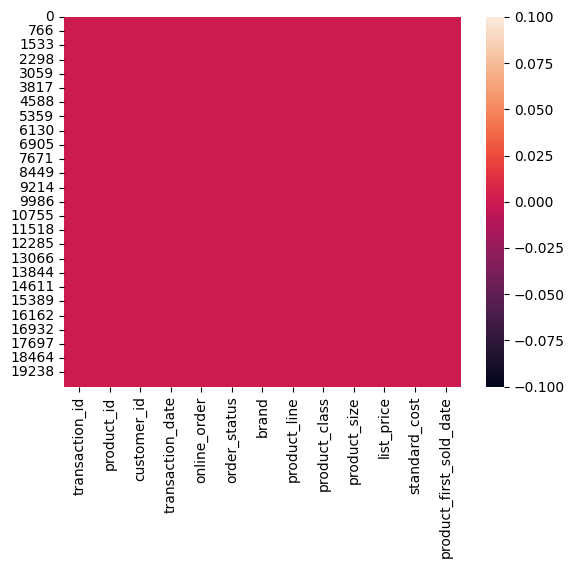

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(Transactions.isnull())
plt.show()

## Transaction Dataset EDA

In [26]:
def plot_stacked_bars(df, title, size=(18,10), rot=0, legend='upper right', legend_title = ['Online Order True = 1', 'Online Order False =0']):
    ax = df.plot(
    kind='bar',
    stacked=True,
    figsize=size,
    rot=rot,
    title=title
    )
    annotate_stacked_bar(ax, textsize=14)
    plt.legend(legend_title, loc=legend)
    plt.ylabel('Company base (%)')
    plt.show()

def annotate_stacked_bar(ax, pad=0.99, colour='white', textsize=13):
    for p in ax.patches:
        value = str(round(p.get_height(), 1))
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

In [27]:
online_order = Transactions[['transaction_id', 'online_order']]
online_order.columns = ['Transaction', 'online_order_status']
online_order_total = online_order.groupby(online_order['online_order_status']).count()
online_order_total

,Transaction
online_order_status,
0,9706
1,9739


In [28]:
online_order_percent = online_order_total/online_order_total.sum() *100

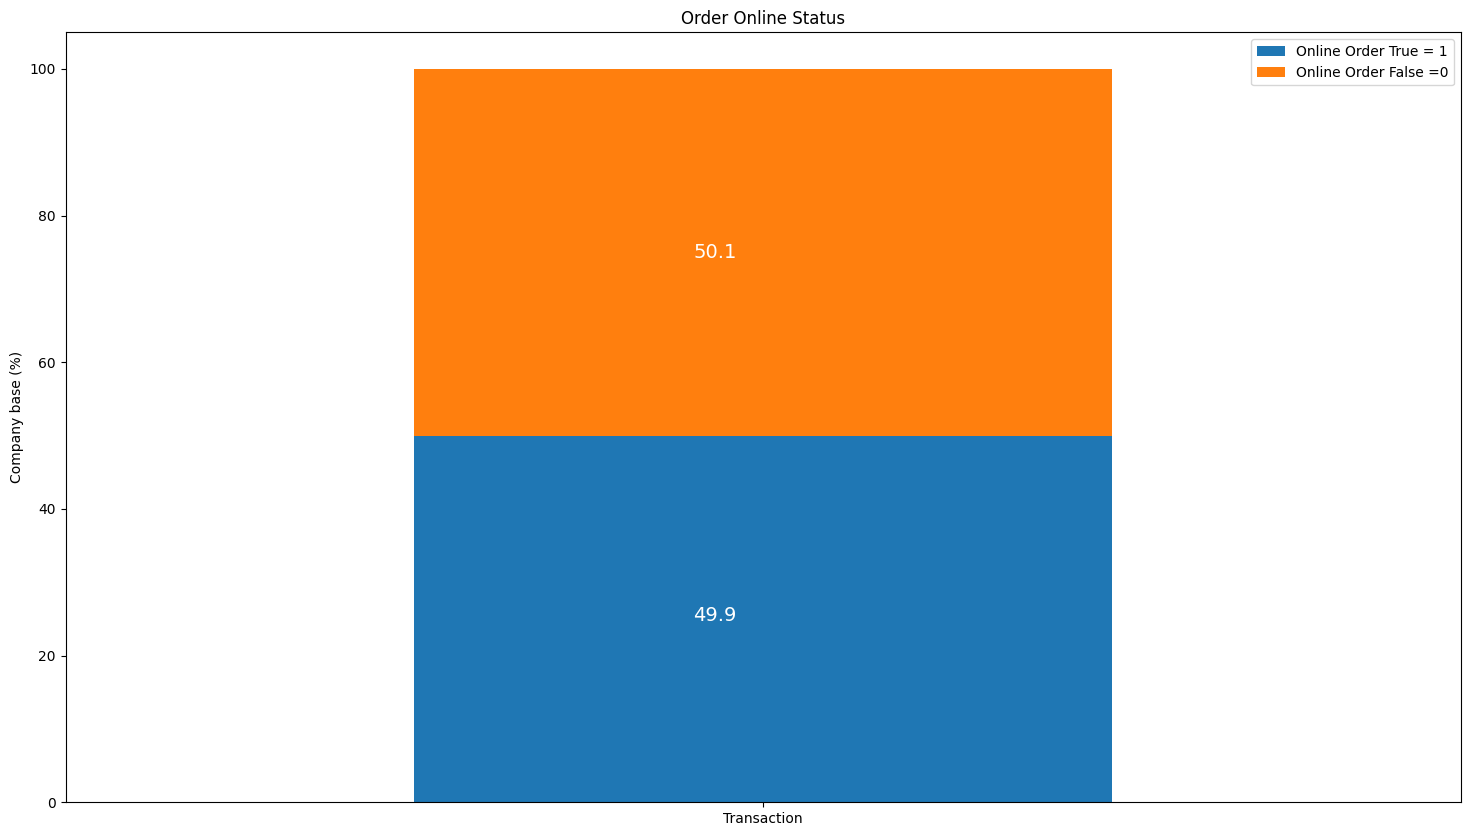

online_order
1    9739
0    9706
Name: count, dtype: int64


In [29]:
plot_stacked_bars(online_order_percent.transpose(), "Order Online Status")
print(Transactions['online_order'].value_counts())

In [30]:
order_status = Transactions[['transaction_id', 'order_status']]
order_status.columns = ['Transaction_id', 'Order_status']
order_status_total = order_status.groupby(order_status['Order_status']).count()
order_status_percent = order_status_total / order_status_total.sum() * 100

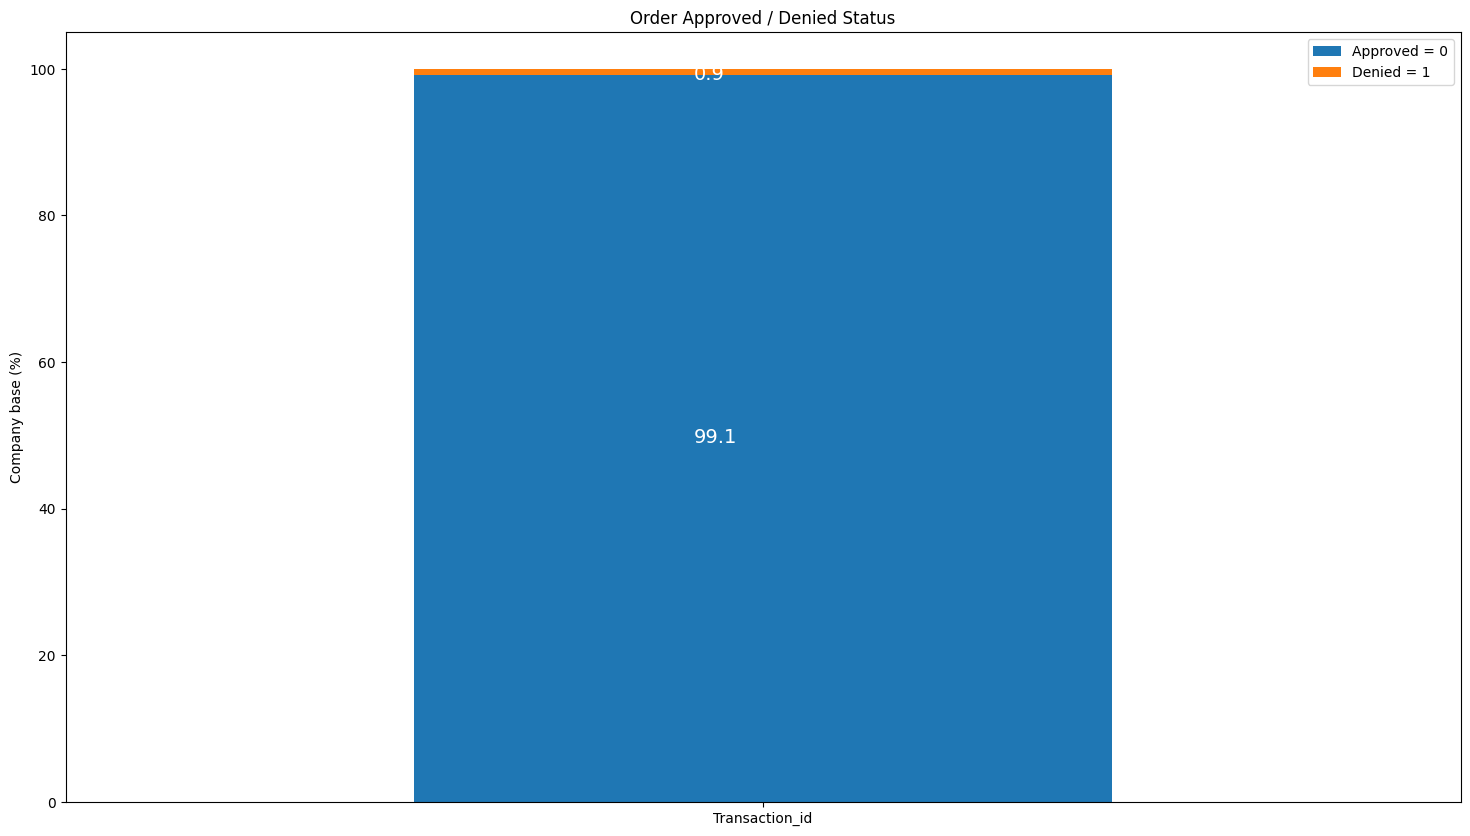

order_status
Approved     19273
Cancelled      172
Name: count, dtype: int64


In [31]:
plot_stacked_bars(order_status_percent.transpose(), "Order Approved / Denied Status", legend_title=['Approved = 0', 'Denied = 1'])
print(Transactions['order_status'].value_counts())

In [32]:
brand = Transactions['brand'].value_counts()
print(brand)

brand
Solex             4169
WeareA2B          3245
Giant Bicycles    3244
OHM Cycles        2993
Trek Bicycles     2931
Norco Bicycles    2863
Name: count, dtype: int64


In [33]:
brand_cost = Transactions[['brand', 'standard_cost']]
brand_cost.columns = ['Brand', 'cost']
brand_total_cost = brand_cost.groupby(brand_cost['Brand'])['cost'].sum()
brand_total_cost.sort_values(ascending=False)

Brand
Giant Bicycles    2.466049e+06
Solex             2.042715e+06
Norco Bicycles    1.760713e+06
Trek Bicycles     1.667448e+06
OHM Cycles        1.481450e+06
WeareA2B          1.384980e+06
Name: cost, dtype: float64

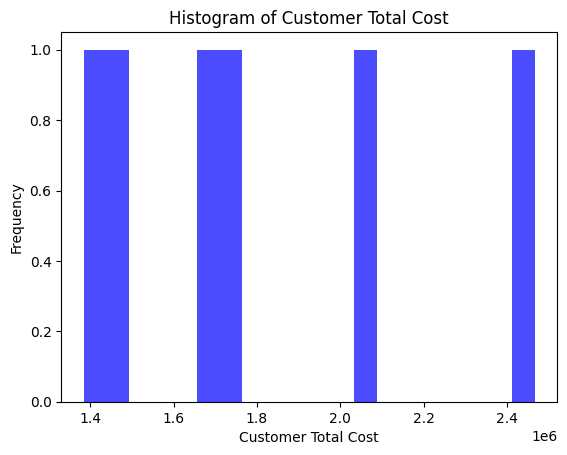

In [34]:
plt.hist(brand_total_cost, bins=20, color='blue', alpha=0.7)
plt.xlabel('Customer Total Cost')
plt.ylabel('Frequency')
plt.title('Histogram of Customer Total Cost')
plt.show()

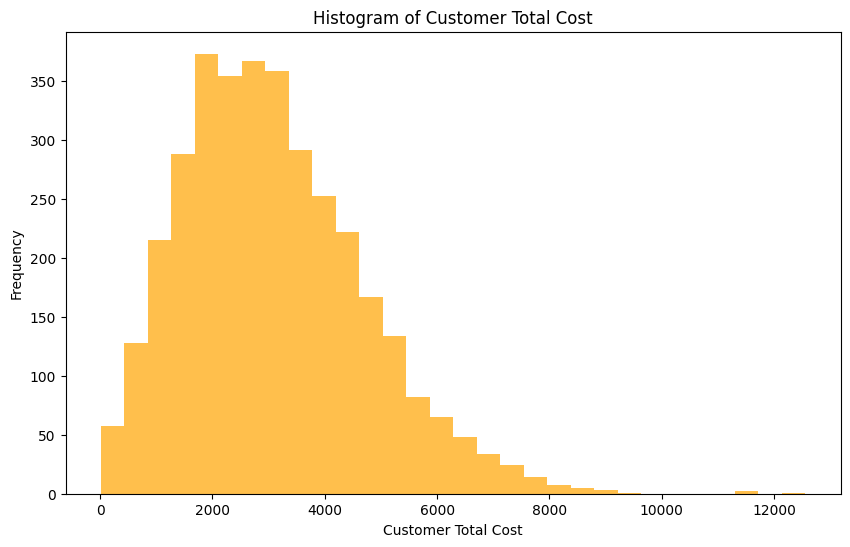

In [35]:
customer_id = Transactions[['customer_id', 'standard_cost']]
customer_id.columns = ['customer_id', 'cost']
customer_id_total_cost = brand_cost.groupby(customer_id['customer_id'])['cost'].sum()
plt.figure(figsize=(10, 6))
plt.hist(customer_id_total_cost, bins=30, color='orange', alpha=0.7)
plt.xlabel('Customer Total Cost')
plt.ylabel('Frequency')
plt.title('Histogram of Customer Total Cost')
plt.show()

In [36]:
customer_id_total_cost

customer_id
1       6066.360000
2       1922.810000
3       6235.010000
4        827.150000
5       3508.260000
           ...     
3497    2095.750000
3498    2029.730000
3499    2718.230000
3500    3136.550000
5034    1250.435028
Name: cost, Length: 3492, dtype: float64

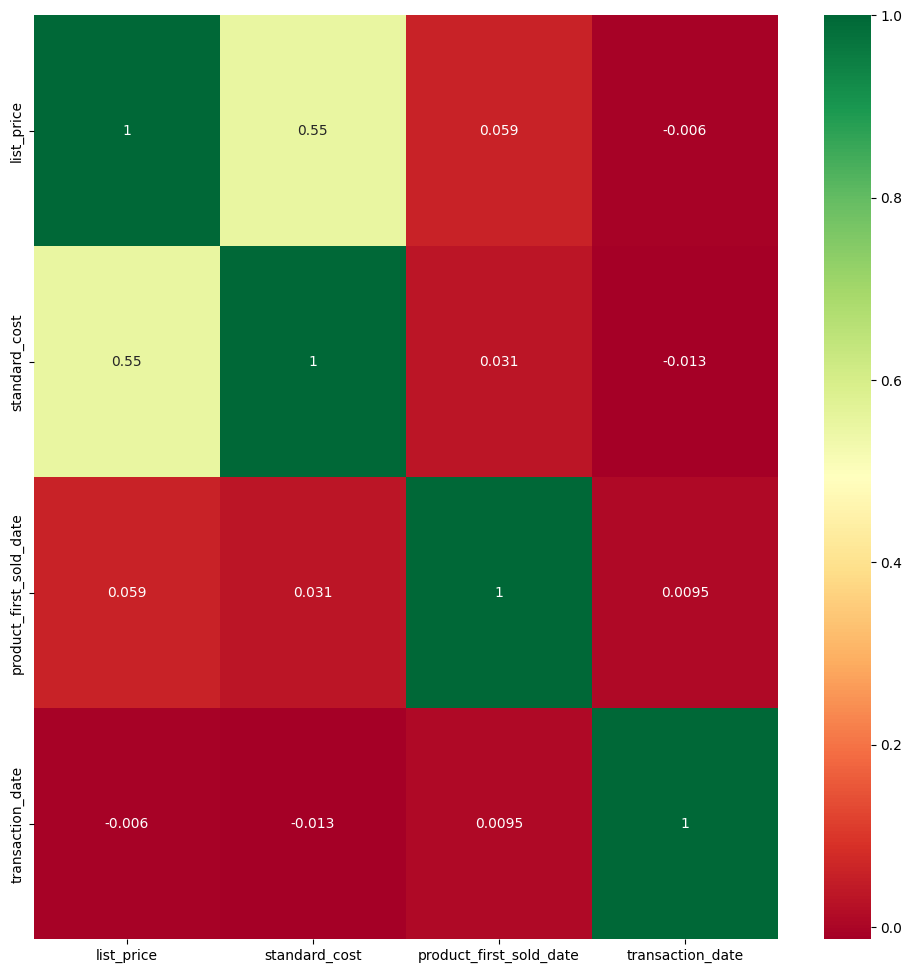

In [37]:
corr = Transactions[Continuous_Variables].corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, annot=True, cmap='RdYlGn', annot_kws={'size':10})
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [38]:
pd.pivot_table(Transactions, index='online_order', values=['list_price','standard_cost', 'product_first_sold_date'])

,list_price,product_first_sold_date,standard_cost
online_order,,,
0,1107.878419,38199.158150,552.768214
1,1106.797802,38204.350344,558.392761


In [39]:
Categorical_Variables

['customer_id',
 'order_status',
 'product_class',
 'product_size',
 'brand',
 'product_line',
 'online_order',
 'customer_id',
 'product_id',
 'transaction_id']

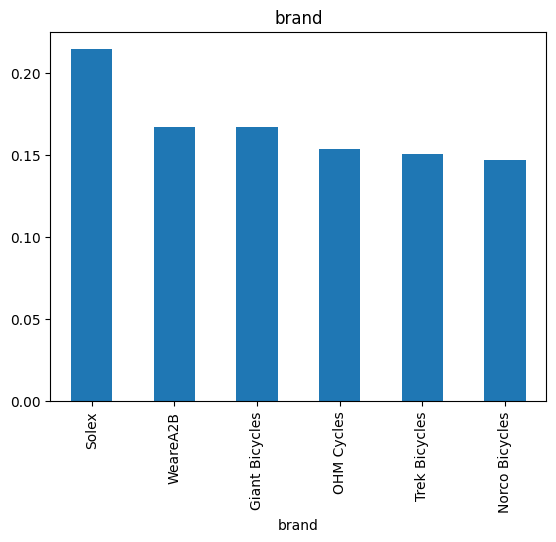

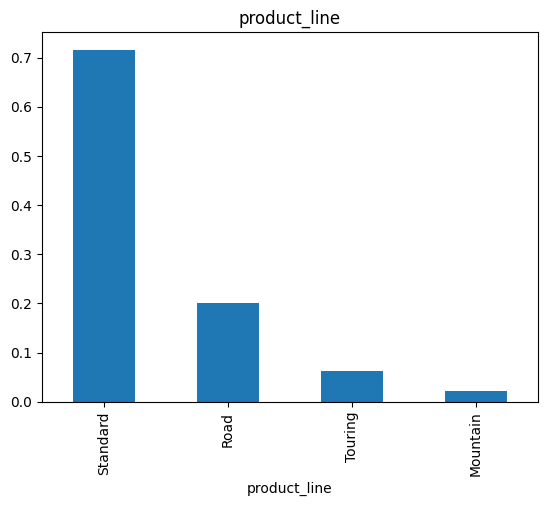

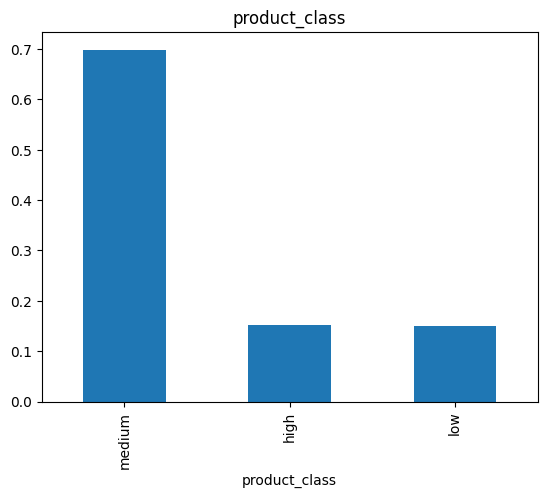

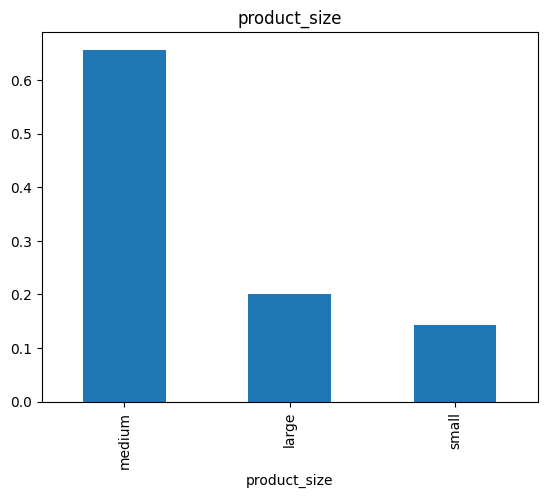

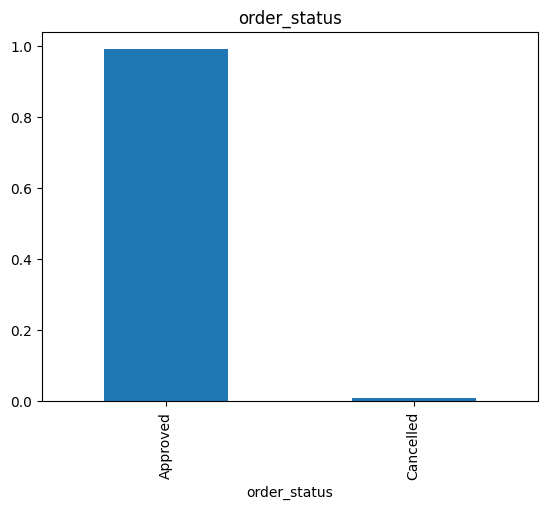

In [40]:
df_cat = Transactions[['brand', 'product_line', 'product_class', 'product_size', 'order_status']] #categorical variables

for i in df_cat.columns:
    df_cat[i].value_counts(normalize=True).plot(kind='bar')
    plt.title(i)
    plt.show()

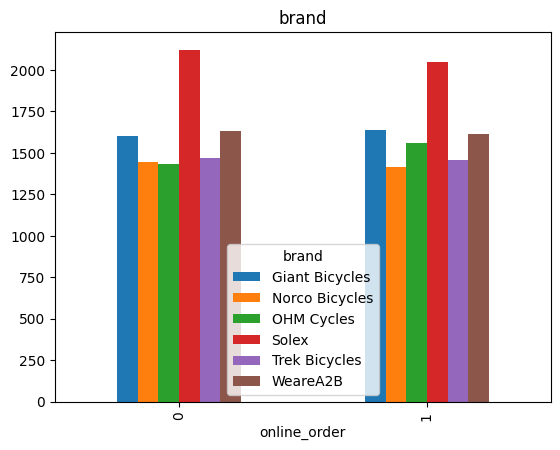

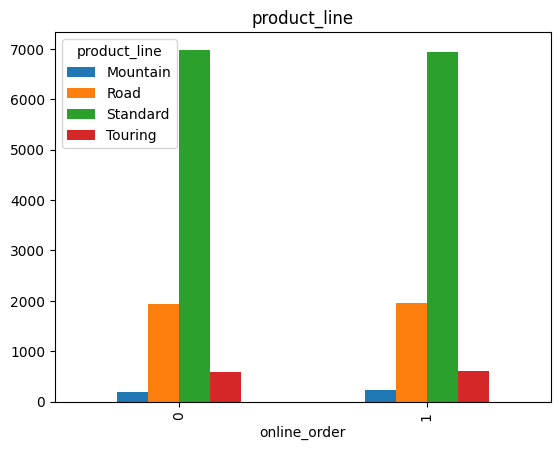

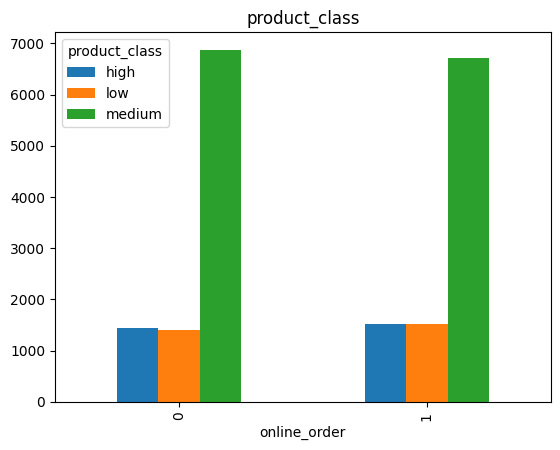

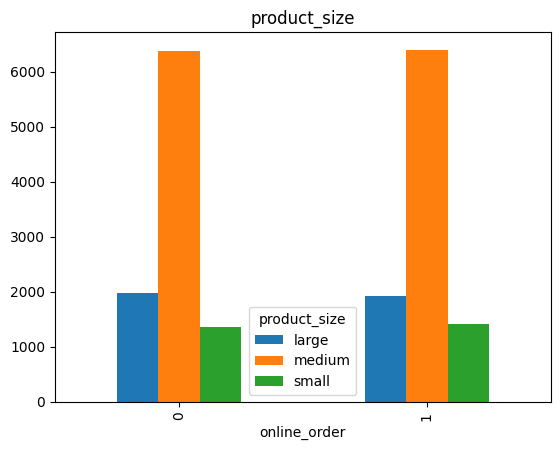

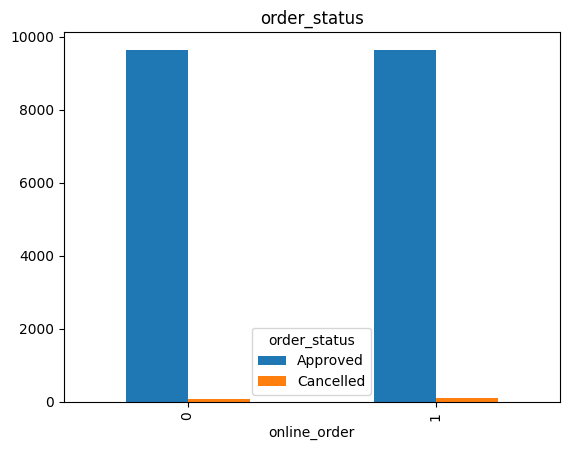

In [41]:
for i in df_cat.columns:
    pd.pivot_table(Transactions, index='online_order', columns=i, values='standard_cost', aggfunc='count').plot(kind='bar')
    plt.title(i)
    plt.show()

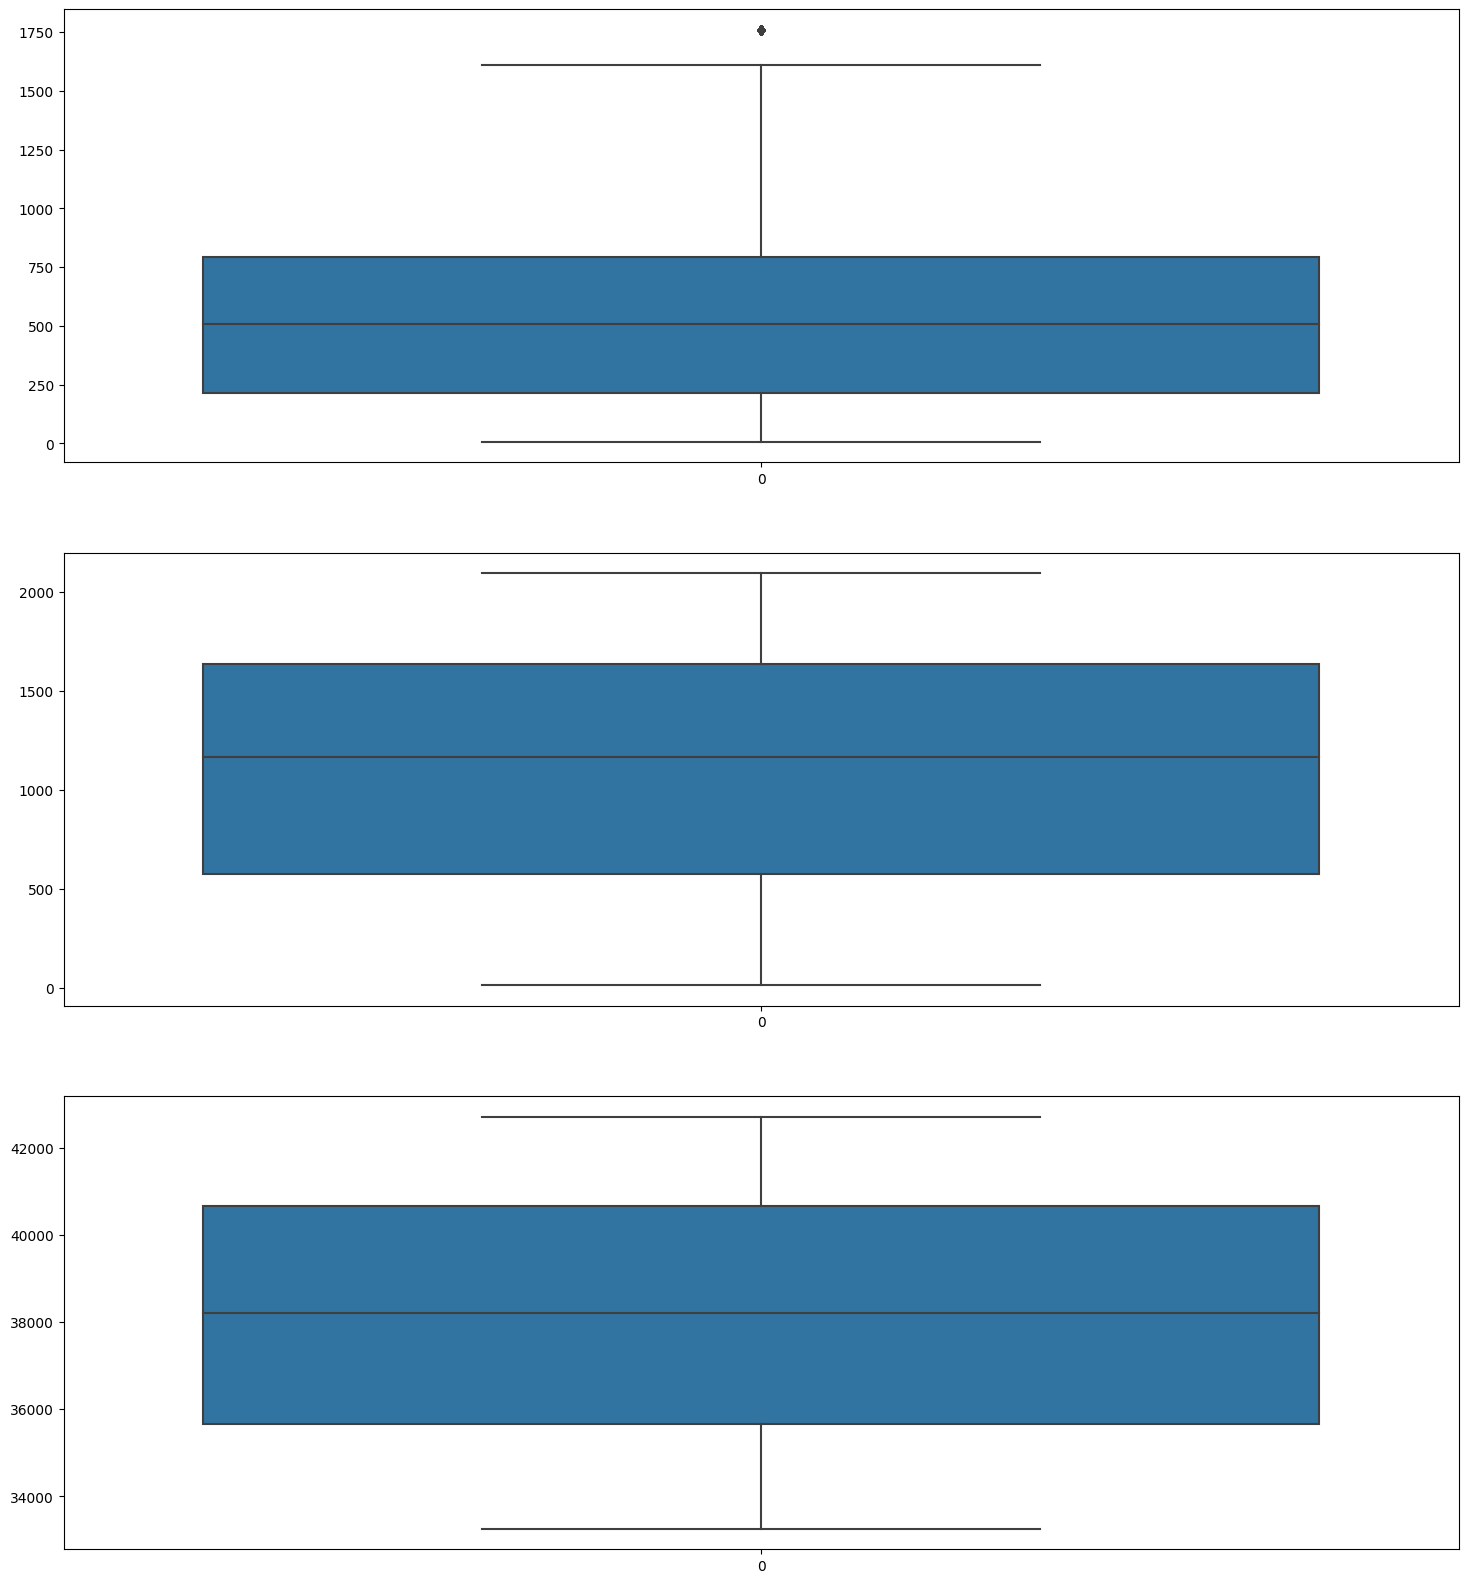

In [42]:
fig, axs = plt.subplots(nrows=3, figsize=(18,20))

sns.boxplot(Transactions['standard_cost'], ax=axs[0])
sns.boxplot(Transactions['list_price'], ax=axs[1])
sns.boxplot(Transactions['product_first_sold_date'], ax=axs[2]);

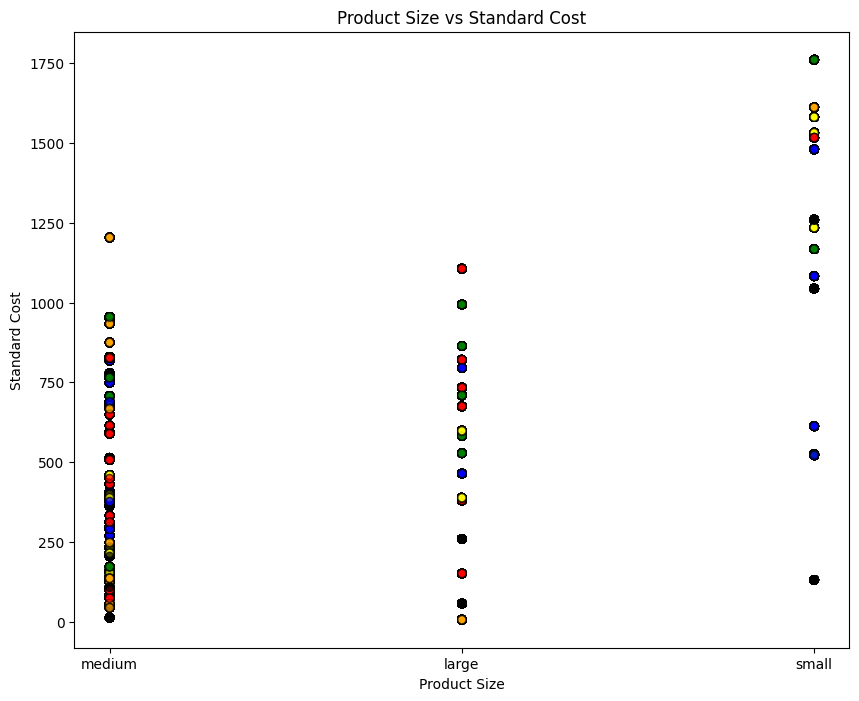

In [43]:
#Brands=['Solex' 'Trek Bicycles' 'OHM Cycles' 'Norco Bicycles' 'Giant Bicycles' 'WeareA2B']
plt.figure(figsize=(10,8))
brand_colours = {
    'Solex':'red',
    'Trek Bicycles':'yellow',
    'OHM Cycles':'orange',
    'Norco Bicycles':'blue',
    'Giant Bicycles':'green',
    'WeareA2B':'black',

}
colour = [brand_colours[i] for i in Transactions['brand']]
plt.scatter(Transactions['product_size'], Transactions['standard_cost'], c=colour, alpha=0.7, edgecolors='k')
plt.xlabel('Product Size')
plt.ylabel('Standard Cost')
plt.title('Product Size vs Standard Cost')
plt.show()

In [44]:
def plot_distribution(columns):
    for i in columns:
        temp = Transactions.groupby(i)['standard_cost'].sum()
        temp.plot(kind='bar', color='green')
        plt.show()

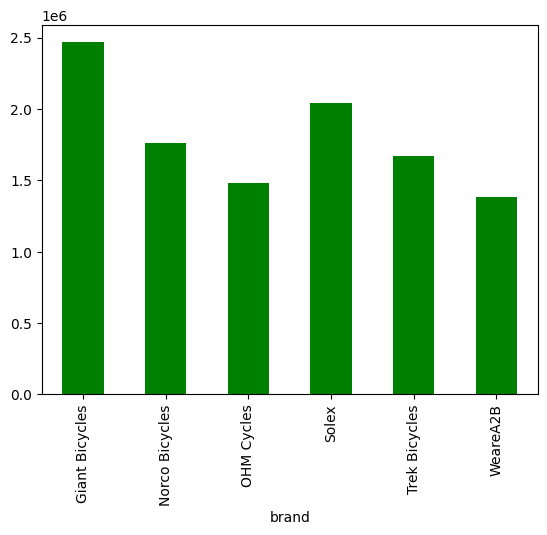

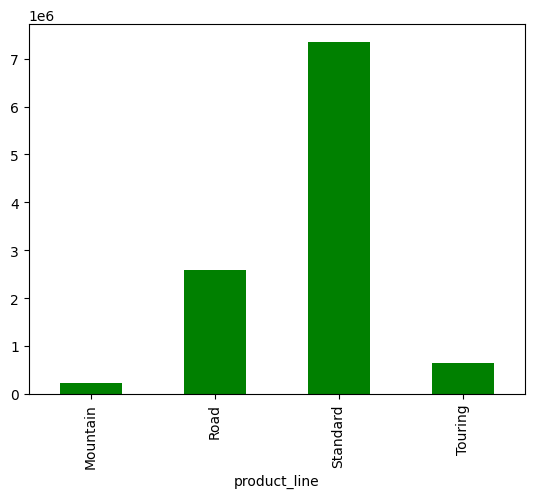

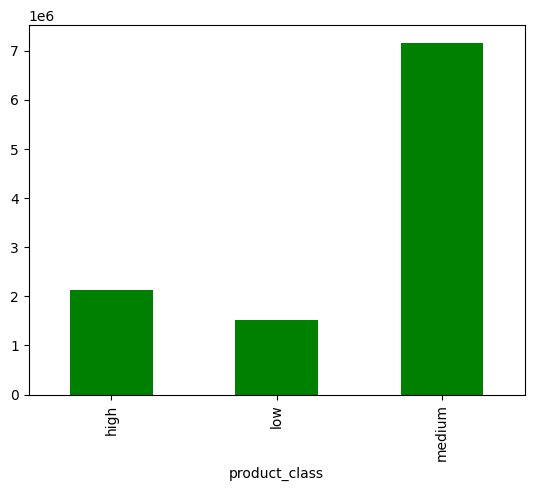

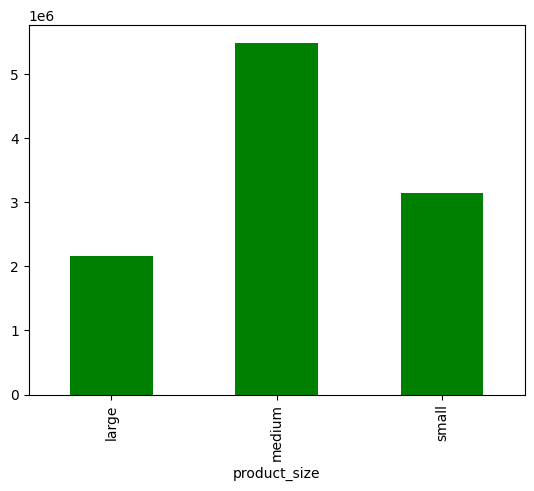

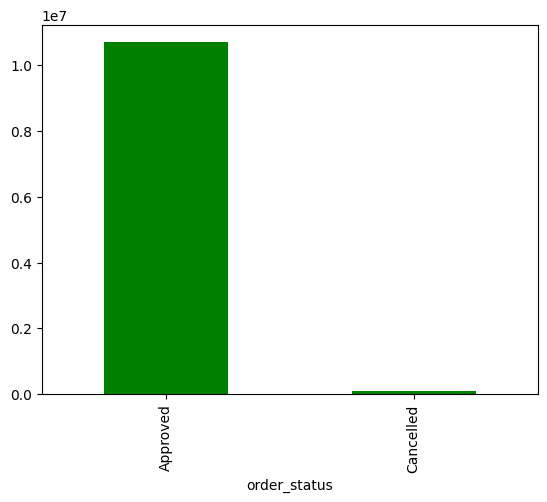

In [45]:
plot_distribution(df_cat.columns)

In [46]:
def plot_distribution(columns):
    for i in columns:
        temp = Transactions.groupby(i)['list_price'].sum()
        temp.plot(kind='bar', color='purple')
        plt.show()

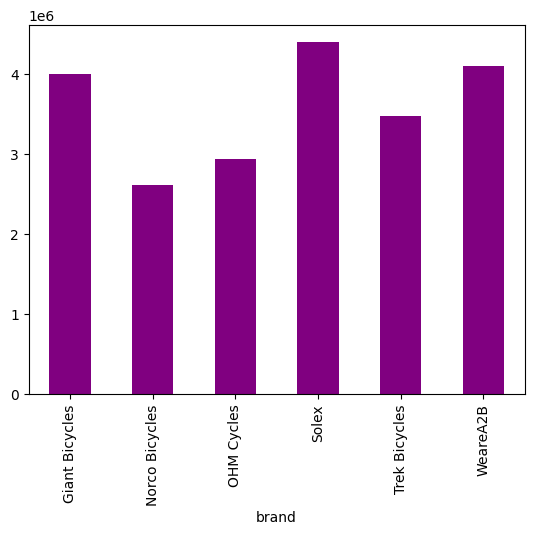

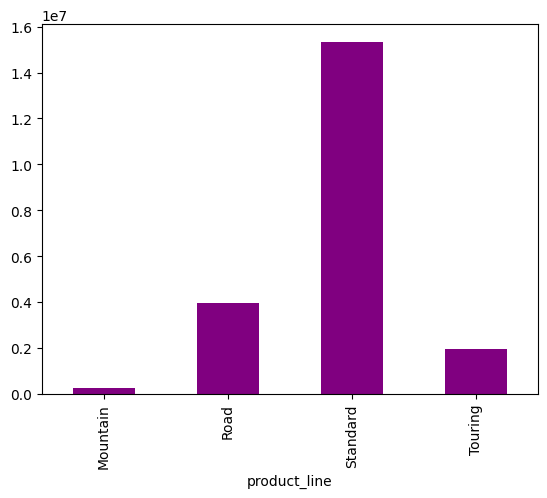

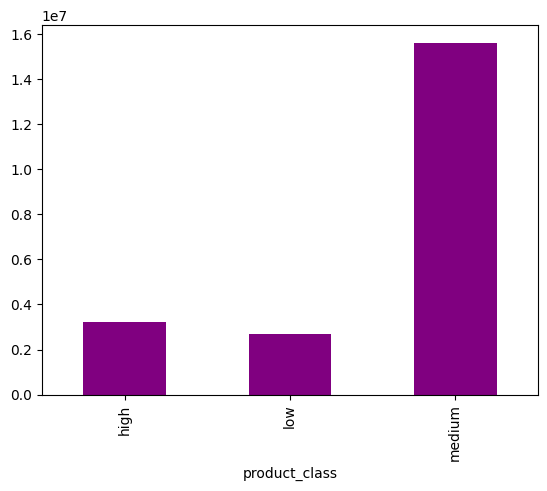

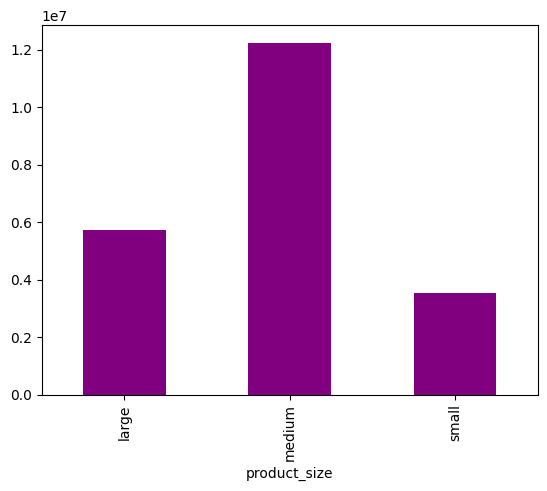

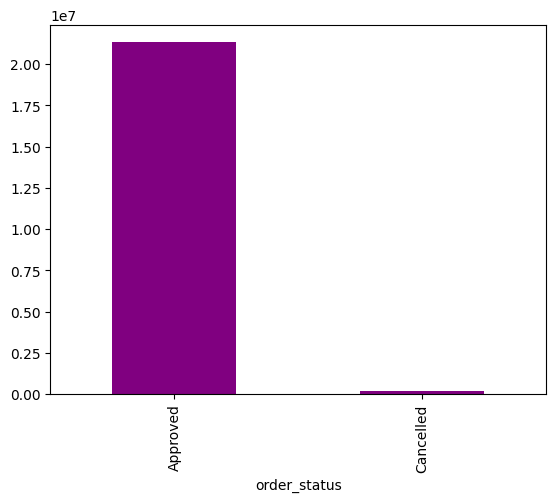

In [47]:
plot_distribution(df_cat.columns)

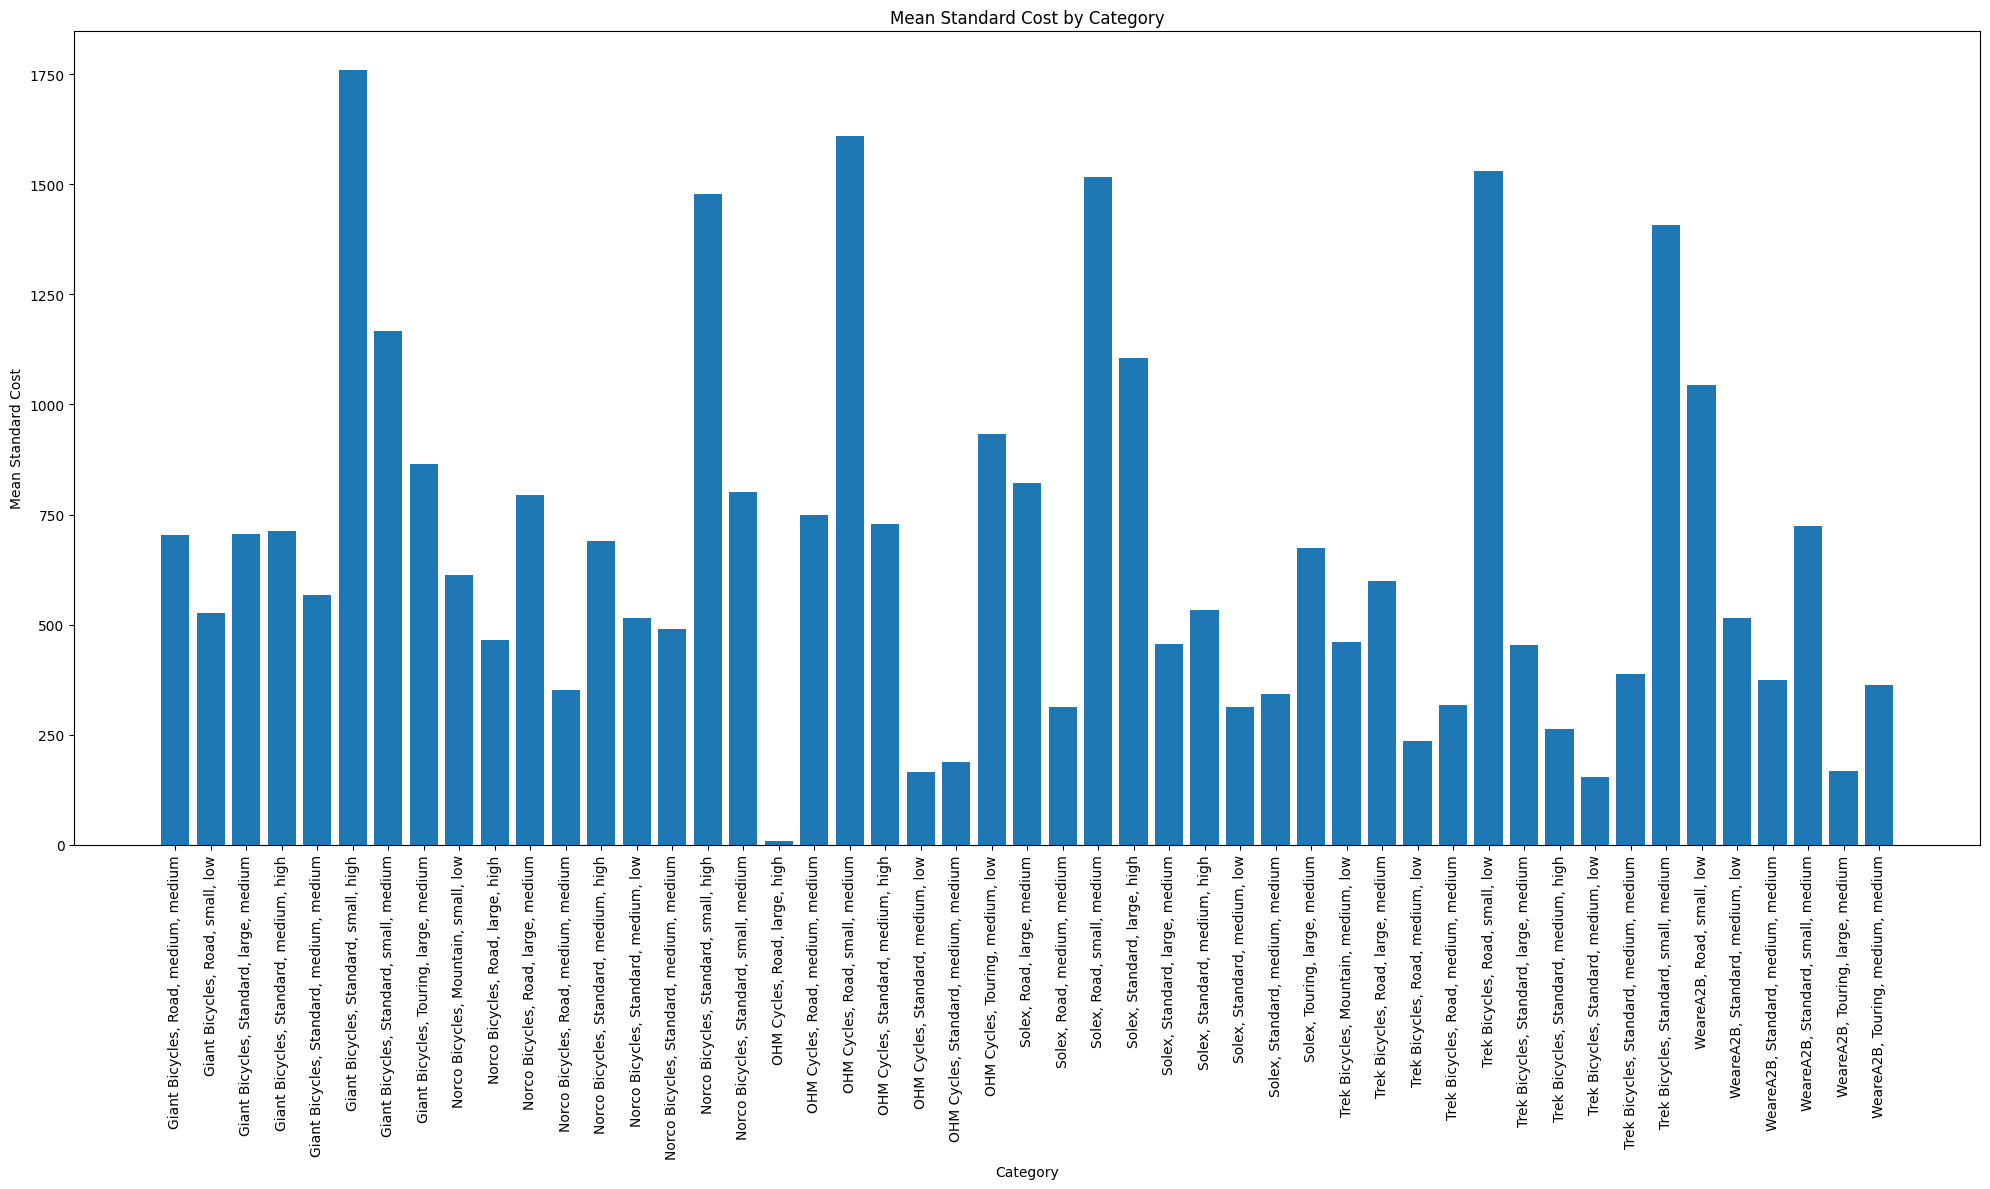

In [48]:
result = Transactions.groupby(['brand', 'product_line', 'product_size', 'product_class'])['standard_cost'].mean().reset_index()
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
plt.bar(range(len(result)), result['standard_cost'], tick_label=result.apply(lambda x: f"{x['brand']}, {x['product_line']}, {x['product_size']}, {x['product_class']}", axis=1))
plt.xticks(rotation=90)
plt.xlabel('Category')
plt.ylabel('Mean Standard Cost')
plt.title('Mean Standard Cost by Category')
plt.tight_layout()

plt.show()

In [49]:
import numpy as np

In [50]:
# standard scaling
Transactions['standard_cost'] = np.log10(Transactions['standard_cost']+1)
Transactions['list_price'] = np.log10(Transactions['list_price']+1)
Transactions['product_first_sold_date'] = np.log10(Transactions['product_first_sold_date']+1)

/tmp/ipykernel_13/3020728014.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Transactions['standard_cost']), ax=axs[0], color='g')
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_13/3020728014.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-l

<Axes: xlabel='product_first_sold_date', ylabel='Density'>

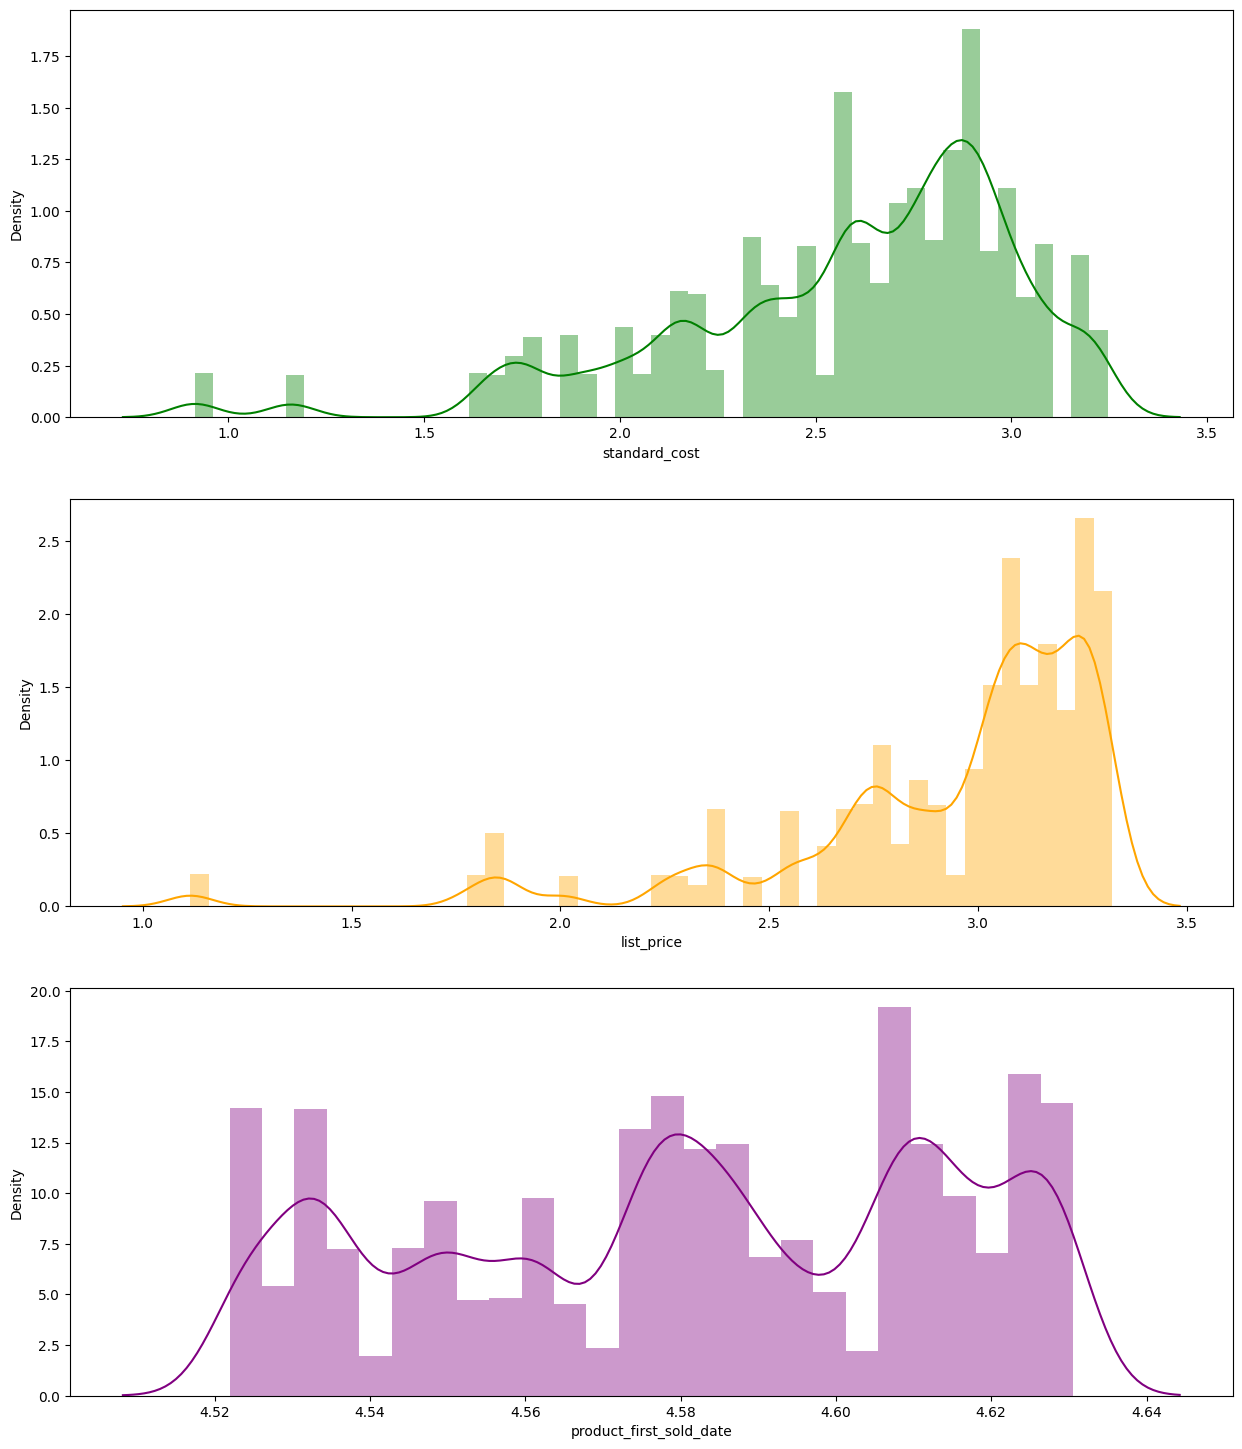

In [52]:
fig, axs = plt.subplots(nrows=3, figsize=(15,18))
sns.distplot((Transactions['standard_cost']), ax=axs[0], color='g')
sns.distplot((Transactions['list_price']), ax=axs[1], color='orange')
sns.distplot((Transactions['product_first_sold_date']), ax=axs[2], color='purple')

In [53]:
#Label Encoding of Categorical variables
from sklearn.preprocessing import LabelEncoder

label_encoders = {}  # Dictionary to store LabelEncoders per column
columns_to_encode = ['order_status', 'product_class', 'product_size', 'brand', 'product_line']

for column in columns_to_encode:
    le = LabelEncoder()
    Transactions[column] = le.fit_transform(Transactions[column])
    label_encoders[column] = le  # Save the fitted encoder for decoding later

Transactions.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,0,0,3,2,2,1,1.860278,1.737352,4.615382
1,2,3,3120,2017-05-21,1,0,4,2,2,0,3.320659,2.590976,4.620157
2,3,37,402,2017-10-16,0,0,2,2,1,1,3.253927,2.397627,4.560648
3,4,88,3135,2017-08-31,0,0,1,2,2,1,3.078986,2.582177,4.558060
4,5,78,787,2017-10-01,1,0,0,2,2,0,3.247064,2.851552,4.625590


In [55]:
for column, encoder in label_encoders.items():
    print(f"\nEncoding for column: {column}")
    for label, encoded_value in zip(encoder.classes_, encoder.transform(encoder.classes_)):
        print(f"  {label} --> {encoded_value}")


Encoding for column: order_status
  Approved --> 0
  Cancelled --> 1

Encoding for column: product_class
  high --> 0
  low --> 1
  medium --> 2

Encoding for column: product_size
  large --> 0
  medium --> 1
  small --> 2

Encoding for column: brand
  Giant Bicycles --> 0
  Norco Bicycles --> 1
  OHM Cycles --> 2
  Solex --> 3
  Trek Bicycles --> 4
  WeareA2B --> 5

Encoding for column: product_line
  Mountain --> 0
  Road --> 1
  Standard --> 2
  Touring --> 3


In [58]:
CustomerAddress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         3999 non-null   int64 
 1   address             3999 non-null   object
 2   postcode            3999 non-null   int64 
 3   state               3999 non-null   object
 4   country             3999 non-null   object
 5   property_valuation  3999 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 187.6+ KB


In [62]:
print("Customer Id: ",CustomerAddress['customer_id'].nunique())
print("Post code: ", CustomerAddress['postcode'].nunique())
print("State: ", CustomerAddress['state'].unique())
print("Country: ", CustomerAddress['country'].unique())
print("Address: ", CustomerAddress['address'].nunique())

Customer Id:  3999
Post code:  873
State:  ['New South Wales' 'QLD' 'VIC' 'NSW' 'Victoria']
Country:  ['Australia']
Address:  3996


## Customer Address Dataset EDA

In [64]:
Cat_var=['customer_id','address','postcode','state','country']
Cont_var=['property_valuation']

             state  customer_id
0              NSW         2054
3              VIC          939
2              QLD          838
1  New South Wales           86
4         Victoria           82


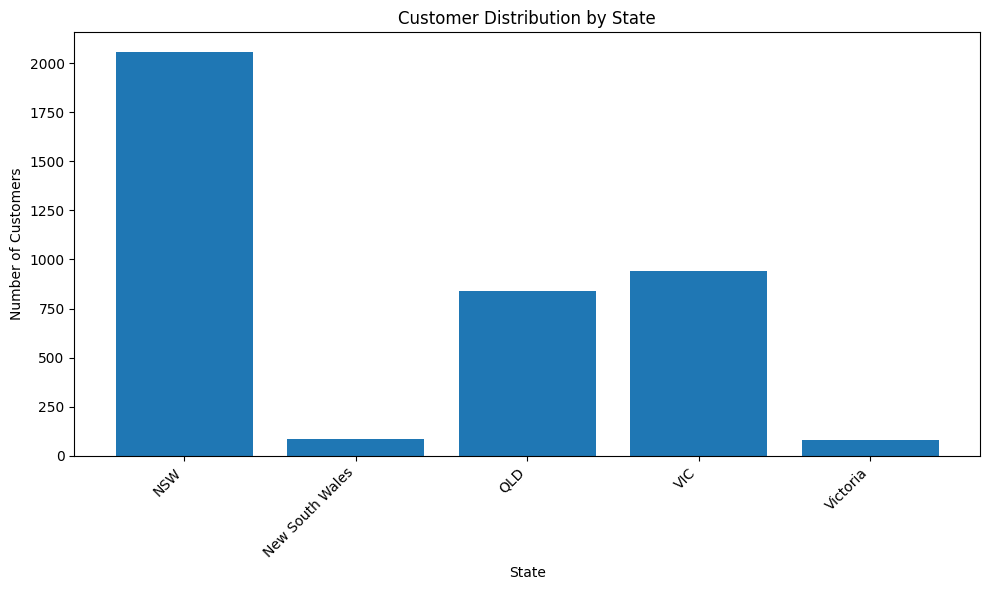

In [65]:
#plot customer distribution per state
import matplotlib.pyplot as plt

# Group by state and count customers
state_counts = CustomerAddress.groupby('state')['customer_id'].count().reset_index()
print(state_counts.sort_values(by=['customer_id'], ascending=False))

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(state_counts['state'], state_counts['customer_id'])
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by State')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()
plt.show()

     postcode  customer_id
132      2170           31
119      2155           30
110      2145           30
117      2153           29
302      2560           26
..        ...          ...
512      3160            1
506      3151            1
499      3144            1
494      3139            1
872      4883            1

[873 rows x 2 columns]


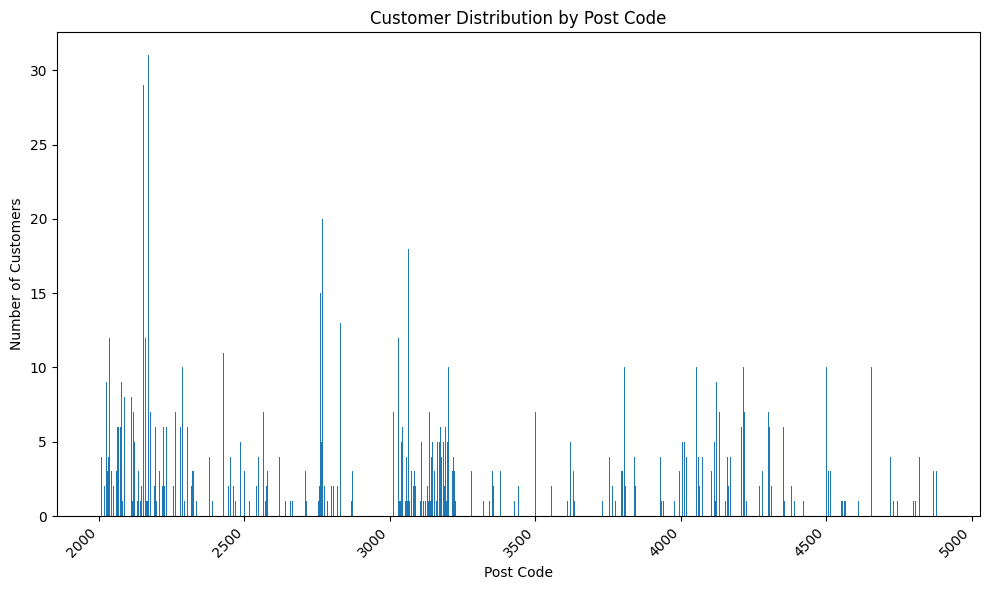

In [66]:
#plot customer distribution per postal code
# Group by postcode and count customers
postcode_counts = CustomerAddress.groupby('postcode')['customer_id'].count().reset_index()
print(postcode_counts.sort_values(by=['customer_id'], ascending=False))
# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(postcode_counts['postcode'], postcode_counts['customer_id'])
plt.xlabel('Post Code')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Post Code')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()
plt.show()

In [67]:
#Average Property Valuation per State
average_valuation_per_state = CustomerAddress.groupby('state')['property_valuation'].mean()
print(average_valuation_per_state)

state
NSW                8.362707
New South Wales    9.081395
QLD                5.569212
VIC                7.237487
Victoria           7.670732
Name: property_valuation, dtype: float64


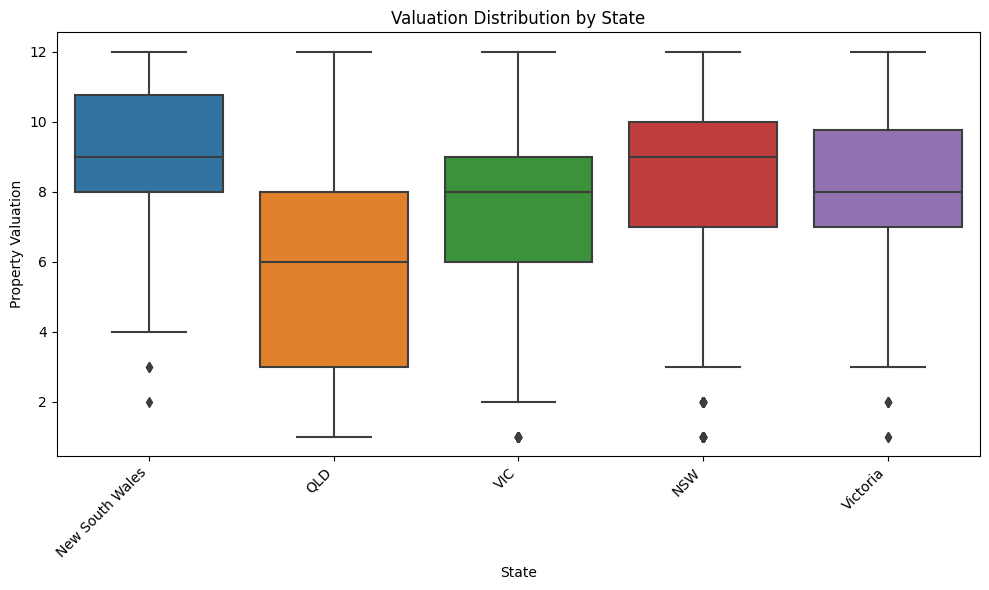

In [68]:
# Valuation Distribution by State:
import seaborn as sns

# Create box plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.boxplot(x='state', y='property_valuation', data=CustomerAddress)
plt.xlabel('State')
plt.ylabel('Property Valuation')
plt.title('Valuation Distribution by State')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()
plt.show()

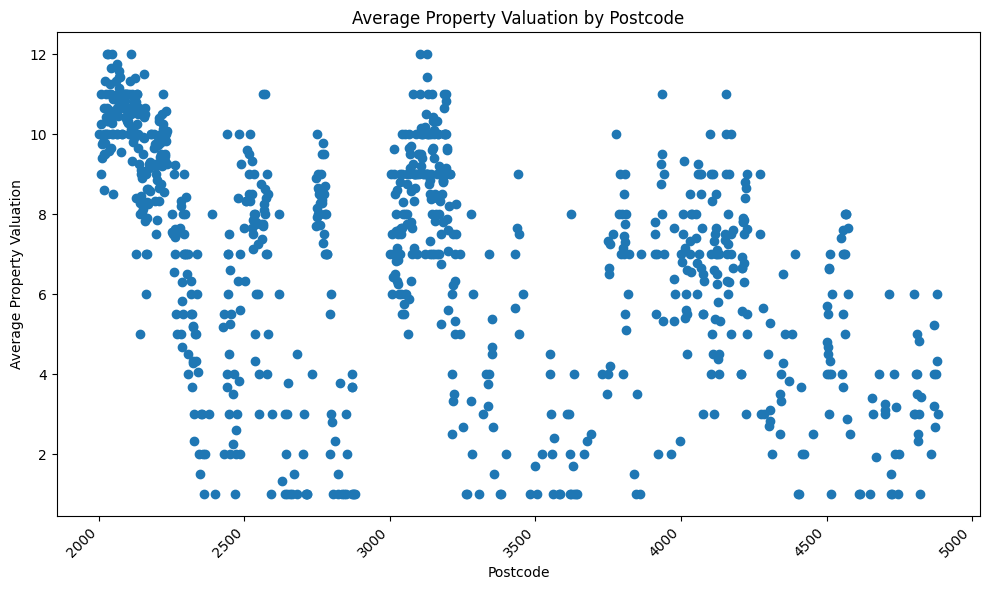

In [69]:
#Explore correlation or patterns by grouping by postcode.
import matplotlib.pyplot as plt

# Group by postcode and calculate average property valuation
postcode_valuation = CustomerAddress.groupby('postcode')['property_valuation'].mean().reset_index()

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(postcode_valuation['postcode'], postcode_valuation['property_valuation'])
plt.xlabel('Postcode')
plt.ylabel('Average Property Valuation')
plt.title('Average Property Valuation by Postcode')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [70]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}  # Dictionary to store LabelEncoders per column
columns_to_encode = ['state', 'postcode']

for column in columns_to_encode:
    le = LabelEncoder()
    CustomerAddress[column] = le.fit_transform(CustomerAddress[column])
    label_encoders[column] = le  # Save the fitted encoder for decoding later

In [71]:
for column, encoder in label_encoders.items():
    print(f"\nEncoding for column: {column}")
    for label, encoded_value in zip(encoder.classes_, encoder.transform(encoder.classes_)):
        print(f"  {label} --> {encoded_value}")


Encoding for column: state
  NSW --> 0
  New South Wales --> 1
  QLD --> 2
  VIC --> 3
  Victoria --> 4

Encoding for column: postcode
  2000 --> 0
  2007 --> 1
  2008 --> 2
  2009 --> 3
  2010 --> 4
  2011 --> 5
  2015 --> 6
  2016 --> 7
  2017 --> 8
  2018 --> 9
  2019 --> 10
  2020 --> 11
  2021 --> 12
  2022 --> 13
  2023 --> 14
  2024 --> 15
  2025 --> 16
  2026 --> 17
  2027 --> 18
  2028 --> 19
  2029 --> 20
  2030 --> 21
  2031 --> 22
  2032 --> 23
  2033 --> 24
  2034 --> 25
  2035 --> 26
  2036 --> 27
  2037 --> 28
  2038 --> 29
  2040 --> 30
  2041 --> 31
  2042 --> 32
  2043 --> 33
  2044 --> 34
  2045 --> 35
  2046 --> 36
  2047 --> 37
  2048 --> 38
  2049 --> 39
  2050 --> 40
  2060 --> 41
  2061 --> 42
  2062 --> 43
  2063 --> 44
  2064 --> 45
  2065 --> 46
  2066 --> 47
  2067 --> 48
  2068 --> 49
  2069 --> 50
  2070 --> 51
  2071 --> 52
  2072 --> 53
  2073 --> 54
  2074 --> 55
  2075 --> 56
  2076 --> 57
  2077 --> 58
  2079 --> 59
  2081 --> 60
  2085 --> 61
  2086

In [ ]:
df_NewCustomerList = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "archit9406/customer-transaction-dataset",
    file_path,
    pandas_kwargs=
        {
        "sheet_name": "NewCustomerList",
        "header": 1
    }
)

In [ ]:
df_CustomerDemographic = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "archit9406/customer-transaction-dataset",
    file_path,
    pandas_kwargs={
        "sheet_name": "CustomerDemographic"
    }
    
)

In [ ]:
print("New Customer: ", df_NewCustomerList.shape)
print("Customer demographic: ", df_CustomerDemographic.shape)
NewCustomerList=df_NewCustomerList.copy()
CustomerDemographic=df_CustomerDemographic.copy()

In [ ]:
NewCustomerList.describe(include='all').T

In [ ]:
# Fill null values with "NA"
NewCustomerList['last_name'] = NewCustomerList['last_name'].fillna("Unknown")
NewCustomerList['DOB'] = NewCustomerList['DOB'].fillna("1900-01-01")
NewCustomerList.loc[NewCustomerList['job_title'].isnull(), 'job_title'] = "Unknown"
NewCustomerList.loc[NewCustomerList['job_industry_category'].isnull(), 'job_industry_category'] = "Unknown Industry"

In [ ]:
NewCustomerList = NewCustomerList.loc[:, ~NewCustomerList.columns.str.contains('^Unnamed')]

In [ ]:
# Convert 'DOB' to datetime, coercing errors to NaT
NewCustomerList['DOB'] = pd.to_datetime(NewCustomerList['DOB'], errors='coerce')

# Identify rows with invalid DOB (NaT values)
invalid_dob_rows = NewCustomerList[NewCustomerList['DOB'].isnull()]
print(len(invalid_dob_rows))

Categorical_var=['first_name', 'last_name', 'gender', 'job_title', 'job_industry_category', 'wealth_segment', 'deceased_indicator', 'owns_car', 'state', 'country']
Continuous_var=['Value', 'Rank', 'postcode', 'property_valuation','past_3_years_bike_related_purchases','DOB','tenure']

In [ ]:
#Check for unique values
print(f"Gender: {NewCustomerList['gender'].unique()}")
print(f"State: {NewCustomerList['state'].unique()}")
print(f"Job Title: {NewCustomerList['job_title'].nunique()}")
print(f"Job Industry Category: {NewCustomerList['job_industry_category'].unique()}")
print(f"Wealth Segment: {NewCustomerList['wealth_segment'].unique()}")
print(f"deceased_indicator: {NewCustomerList['deceased_indicator'].unique()}")
print(f"owns_car: {NewCustomerList['owns_car'].unique()}")

In [ ]:
# Filter rows with "unknown" gender
unknown_gender_rows = NewCustomerList['gender'] == 'U'

# Get the number of "unknown" gender rows
num_unknown = unknown_gender_rows.sum()

# Calculate the number of rows to replace with "Male" and "Female"
num_male = num_unknown // 2
num_female = num_unknown - num_male

# Replace "unknown" with "Male" and "Female" proportionally
NewCustomerList.loc[unknown_gender_rows, 'gender'] = np.random.choice(['Male', 'Female'], size=num_unknown, p=[0.5, 0.5])

In [ ]:
gender_counts = NewCustomerList['gender'].value_counts()
print(gender_counts)


In [ ]:
#for 'job_industry_category'
NewCustomerList['job_industry_category'].value_counts().plot(kind='bar')
plt.title('Distribution of Job Industry Category')
plt.xlabel('Job Industry Category')
plt.ylabel('Count')
plt.show()

In [ ]:
#for 'wealth_segment'
wealth_segment_counts = NewCustomerList['wealth_segment'].value_counts()
wealth_segment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Wealth Segment')
plt.show()

In [ ]:
# for 'gender' and 'owns_car'
cross_tab = pd.crosstab(NewCustomerList['gender'], NewCustomerList['owns_car'])
print(cross_tab)

In [ ]:
# Plot distribution of 'job_industry_category' by gender
sns.countplot(data=NewCustomerList, x='job_industry_category', hue='gender')
plt.title('Distribution of Job Industry Category by Gender')
plt.xlabel('Job Industry Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.show()

In [ ]:
NewCustomerList['gender'].value_counts().plot(kind='bar')

In [ ]:
NewCustomerList['job_title'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Job Titles')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.show()

In [ ]:
NewCustomerList['state'].value_counts().head().plot(kind='barh')

In [ ]:
# Gender vs Purchases
sns.boxplot(x='gender', y='past_3_years_bike_related_purchases', data=NewCustomerList)
plt.title('Gender vs Purchases')

In [ ]:
# Wealth Segment vs Property Valuation
sns.boxplot(x='wealth_segment', y='property_valuation', data=NewCustomerList)
plt.title('Wealth Segment vs Property Valuation')

In [ ]:
#Industry vs Tenure
plt.xticks(rotation=90)
sns.boxplot(x='job_industry_category', y='tenure', data=NewCustomerList)